In [2]:
import json
from pathlib import Path

import numpy as np
import cv2
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image

# print debug info about numpy or pytorch array
imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())

In [3]:
# Load DROID or simulation data

#data_path = Path("data/clevr-act-8-clevr-rt")
data_path = Path("data/export-real-1of5-checked")
#data_path = Path("data/export_large")
with open(data_path / "_annotations.all.jsonl", "r") as f:
    lines = [line.strip() for line in f.readlines()]

In [7]:
print(lines[0])

{"date": "2023-03-02-16h-17m-08s", "action_text": "pick up the pen from the table and put in the cup", "camera_intrinsic": [[[522.5827026367188, 0.0, 640.4918212890625], [0.0, 522.5827026367188, 353.23077392578125], [0.0, 0.0, 1.0]]], "camera_extrinsic": [[[0.9888161595674689, -0.14768895475076804, -0.020750306572857334, -0.3820852459423268], [-0.048008128205845615, -0.1834768407521314, -0.9818510419273325, 0.21446583041223238], [0.1412013534085742, 0.971866359924163, -0.18851513531635672, 0.5282642556992795]]], "obj_start_pose": [[0.786652404331741, -0.03599634574138862, -0.03377274912123576, 0.9988571727879691, 0.01779756443648844, 0.005878841320744014, 0.043966285889072254]], "obj_end_pose": [[0.8049740155412353, -0.0483930975944553, -0.01789530532536665, 0.9986659069274388, 0.01201547700959916, -0.014317705306142669, 0.04813562057140628]], "tcp_start_pose": [[0.3000351253582972, -0.12641242307649897, 0.317011434091584, 0.7368310716889392, 0.17266819764331642, 6.842014158079385e-05,

In [8]:
def extract_extrinsics(pose: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Takes a vector [tx ty tz qw qx qy qz] and extracts 
    the translation vector (3) and the rotation matrix (3, 3)
    """
    translation = pose[:3]
    rotation = Rotation.from_quat(np.array(pose[3:]), scalar_first=True).as_matrix()
    return (translation, rotation)

def camera_to_world(t, rot):
    """
    Extrinsic matrix C from local coordinates to world coordinates.
    First rotation, then translation.
    t: (3) translation, world coordinates of local center
    rot: (3,3) rotation
    return: (4,4)
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot
    ext[0:3, 3] = t
    return ext

def world_to_camera(t: np.ndarray, rot: np.ndarray):
    """
    Inverse of C, transform from world coordinates to camera coordinates.
    t: (3) translation
    rot: (3,3) rotation
    return: (4, 4)
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot.T
    ext[0:3, 3] = -rot.T @ t
    return ext

def project(point_3d: np.ndarray, proj: np.ndarray):
    """ 
    Multiply projection matrix by point in homogenous coordinates.
    point_3d: (3)
    proj: (3, 4)
    """
    p3d = np.ones((4))
    p3d[:3] = point_3d # (x y z 2)
    p2d = proj @ p3d # (3, 4) x (4, 1)
    p2d = p2d / p2d[2] # remove homogeneous coordinate
    return p2d[:2]

In [9]:
# === Projection from world to pixels:
# 1) world to camera, C^(-1)
# 2) pinhole
# 3) intrinsic
# 4) divide by last component in homogeneous coordinates

# === Total projection matrix
# point_2d = camera_intrinsic @ camera_extrinsic @ robot_transform @ correction @ point_3d

def load_episode(idx: int):
    """
    Load camera intrinsic, extrinsic,
    object pose at moment of grip, TCP pose at first frame
    caption text, 
    """
    info = json.loads(lines[idx])

    camera_intrinsic = np.array(info["camera_intrinsic"][0]) # (3, 3)
    camera_extrinsic = np.array(info["camera_extrinsic"][0]) # (3, 4)
    # possible keys: obj_start_pose, obj_end_pose, tcp_start_pose, robot_pose
    obj_start_pose = np.array(info["obj_start_pose"][0]) # [x y z qw qx qy qz]
    obj_start_t, obj_start_rot = extract_extrinsics(obj_start_pose)
    
    # possible keys: image, image_grip, image_depth
    image = cv2.imread(data_path / info["image_grip"])[:,:,::-1]

    # Caption
    caption = info["action_text"]

    # Projection matrix
    camera_proj = camera_intrinsic @ camera_extrinsic # (3, 3) x (3, 4), pinhole included in extrinsic

    # Robot = [tx ty tz + qw qx qy qz]
    robot_transform = camera_to_world(obj_start_t, obj_start_rot) # [4, 4]

    # Empirical correction
    _t = np.array([0, 0, 0.16]) # [x y z]
    _rot_euler = [0, np.pi, np.pi/2] # [rx ry rz]
    _rot = Rotation.from_euler("xyz", _rot_euler).as_matrix()
    _correction = camera_to_world(_t, _rot)
    #robot_transform = robot_transform @ _correction

    total_transform = camera_proj @ robot_transform # (3, 4) x (4, 4)
    return [total_transform, image, caption]

pick up the pen from the table and put in the cup
total transform:
<class 'numpy.ndarray'> float64 (3, 4) -587.6191730038752 654.1349320941323


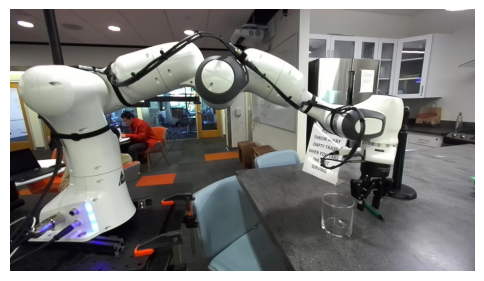

In [17]:
total_transform, image, caption = load_episode(0)
print(caption)
print("total transform:")
imginfo(total_transform)

fig, axs = plt.subplots(1, 1, figsize=(6, 6))
axs.set_axis_off()
axs.imshow(image)

<class 'numpy.ndarray'> uint8 (200, 200, 3) 0 255


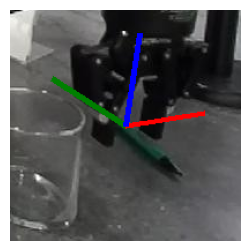

In [19]:
from PIL import ImageDraw

def pad_crop(image: np.ndarray, x: float, y: float, crop_size: int) -> np.ndarray:
    """
    Crop of size (crop_size * 2 + 1, crop_size * 2 + 1)
    """
    # make sure the image has enough padding for correct crop
    _padded = np.pad(image, ((crop_size, crop_size), (crop_size, crop_size), (0, 0)))
    h, w, c = image.shape
    x = int(np.clip(x, 0, w)) + crop_size
    y = int(np.clip(y, 0, h)) + crop_size
    crop = _padded[y - crop_size: y + crop_size, x - crop_size: x + crop_size, :]
    return crop

def show_pose(image, total_transform) -> np.ndarray:
    """
    Draw the coordinate frame into each image.

    1. Define 4 points in 3D homogeneous coordinates: x, y, z, center
       (The center of the coordinate system and a point for each of 3 axes.)
       Note that the 3D here are specified in meters.
    2. Transform the <x, y, z, center> coordinates into the camera frame
    3. Project the homogeneous coordinates <cam_x, cam_y, cam_z, center>
       to the camera image (euclidean)
    4. Draw one line for each axis

    Arguments:
        image: image as numpy.ndarray
        total_transform: transformation matrix from object to camera space, shape (3, 4)
            x_cam = total_transform @ x

    Returns:
        im: image as numpy.ndarray with coordinate frame drawn on it
    """

    # Define points
    dist = 0.1
    c = np.array([0, 0, 0])
    x = np.array([dist, 0, 0])
    y = np.array([0, dist, 0])
    z = np.array([0, 0, dist])

    # Project from object space to image 2D space
    c = project(c, total_transform) # [x y]
    x = project(x, total_transform)
    y = project(y, total_transform)
    z = project(z, total_transform)

    # Draw axis lines
    im = Image.fromarray(image)
    draw = ImageDraw.Draw(im)
    draw.line((c[0], c[1], x[0], x[1]), fill="red", width=5)
    draw.line((c[0], c[1], y[0], y[1]), fill="green", width=5)
    draw.line((c[0], c[1], z[0], z[1]), fill="blue", width=5)

    # convert image back to numpy and crop
    # https://www.pythoninformer.com/python-libraries/numpy/image-operations/
    pose_image = np.asarray(im)
    crop_size = 100
    crop = pad_crop(pose_image, c[0], c[1], crop_size)
    return crop

plot = show_pose(image, total_transform)
imginfo(plot)
fig, ax = plt.subplots(1, figsize=(3,3))
ax.set_axis_off()
ax.imshow(plot)

# Interactive overview

In [26]:
print("episodes:", len(lines))

episodes: 1293


interactive(children=(IntSlider(value=0, description='w', layout=Layout(width='70%'), max=1292), Output()), _d…

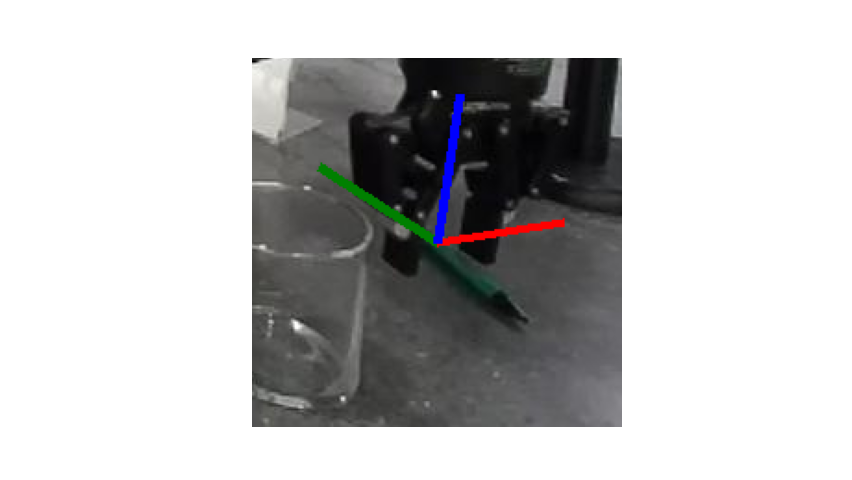

In [27]:
%matplotlib widget
from ipywidgets import widgets, Layout, interact

# interactive image
line = None

def update(w: int):
    global line

    # load episode
    total_transform, image, caption = load_episode(w)

    # draw coordinate frame
    image_m = show_pose(image, total_transform)

    # print episode caption
    print(caption)

    # show image
    if line is None:
        line = ax.imshow(image_m)
    else:
        line.set_data(image_m)
    fig.canvas.draw_idle()

image_width, image_height = int(1280/3*2), int(720/3*2) # display size
dpi = 100
figsize = (image_width / dpi, image_height / dpi)
fig, ax = plt.subplots(1, figsize=figsize, dpi=dpi)
ax.set_axis_off()

slider_w = widgets.IntSlider(
    min=0, max=len(lines)-1, step=1, value=0, layout=Layout(width="70%")
)
interact(update, w=slider_w)
pass

# GT markup

interactive(children=(Text(value='', description='String:', placeholder='Type something'), Output()), _dom_cla…

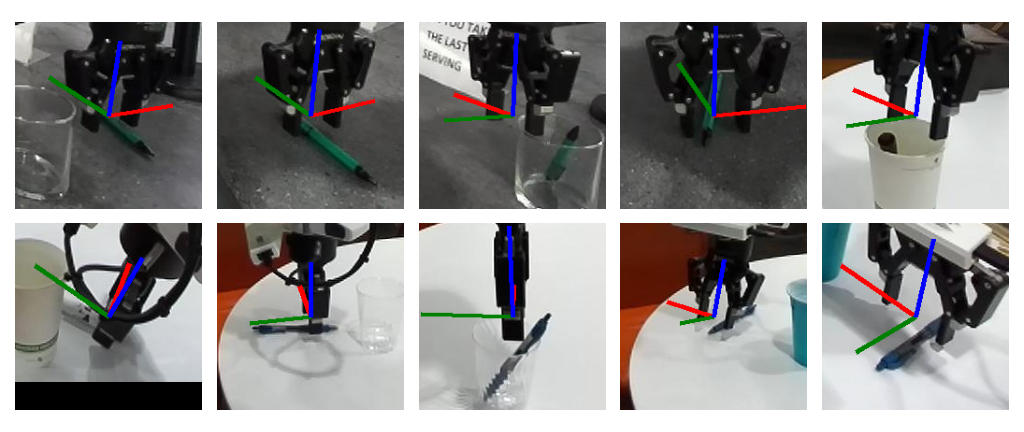

In [30]:
%matplotlib widget
from ipywidgets import widgets, Layout, interact

# Interactive GT markup.
# The text field is cleared after you press a letter.
# y - accept 1 image
# a - accept all
# n - reject 1 image
# x - reject all

gt = [] # indices of good episodes
idx = 0
panel = [None] * 10 # display 10 images at once
preloaded = {} # save loaded episodes in RAM 

def preload(idx):
    """
    Save loaded episodes in RAM
    """
    global preloaded
    if len(preloaded) > 300:
        preloaded = {}
    if not idx in preloaded:
        preloaded[idx] = load_episode(idx)

def update(w: str):
    """
    Interactively display 10 tiles with images.
    This function receives the current keypress.
    """
    
    global idx
    global panel

    # Increment episode index
    if w == "":
        pass
    else:
        if w == "y":
            gt.append(idx)
            idx += 1
        elif w == "n":
            idx += 1
        elif w == "a":
            for add_idx in range(idx, idx + 10):
                gt.append(add_idx)
            idx += 10
        elif w == "x":
            idx += 10

    print("index", idx)
    print("preloaded size", len(preloaded))

    # Show images
    for row in range(2):
        for col in range(5):
            cur = row * 5 + col
            preload(idx + cur)
            total_transform, image, caption = preloaded[idx + cur]
            image_m = show_pose(image, total_transform)

            if panel[cur] is None:
                panel[cur] = axs[row][col].imshow(image_m)
            else:
                panel[cur].set_data(image_m)

            if row == 0 and col == 0:
                print(caption)
    fig.canvas.draw_idle()
    plt.tight_layout()

    # Reset text field
    text_w.value = ""

    # Save GT
    with open("data/gt.json", "w") as f:
        json.dump(gt, f, indent=4, ensure_ascii=False)
    


text_w = widgets.Text(
    value="",
    placeholder="Type something",
    description="String:",
    disabled=False   
)

def callback(wdgt):
    # replace by something useful
    wdgt.value = ""

image_width, image_height = int(1280*0.8), int(720*0.6)
dpi = 100
figsize = (image_width / dpi, image_height / dpi)
fig, axs = plt.subplots(2, 5, figsize=figsize, dpi=dpi)
for i in range(2):
    for j in range(5):
        axs[i][j].set_axis_off()


#text_w.on_submit(callback)

interact(update, w=text_w)
pass

# Copy checked images

In [43]:
import json
import shutil

with open("data/real-v1.5-filtered.json", "r") as f:
    gt = json.load(f)

In [29]:
checked_path = Path("data/export-real-1of5-checked")
checked_path.mkdir(parents=True, exist_ok=True)
with open(checked_path / "_annotations.all.jsonl", "w") as f:
    for i in gt:
        print(lines[i].lower().strip(), file=f)
        info = json.loads(lines[i])
        shutil.copy2(data_path / info["image"], checked_path / info["image"])
        shutil.copy2(data_path / info["image_grip"], checked_path / info["image_grip"])
        shutil.copy2(data_path / info["image_depth"], checked_path / info["image_depth"])
